# CNN-Transformer Comparison - Part 1 (VGG16, MobileNetV3, EfficientNet)

Noise-robust multi-task classification benchmark on RF spectrograms - Part 1 of 2.

## Training Strategy
| Split | SNR Levels | Purpose |
|-------|------------|---------|
| Train | 80% of clean, +05dB, +15dB | Noise diversity: best + bad + moderate (stratified 80/20 split) |
| Val | +00dB | Worst-case validation for early stopping |
| Test | clean(20%), +10dB, +20dB | Interpolation + extrapolation robustness curve |

**Note:** Only 80% of training SNR data is used for training (stratified by drone_type). The remaining 20% is held out to prevent data leakage when evaluating on training SNR levels.

## Models in This Notebook
| Model | Key RF Adaptation | Epochs | Patience |
|-------|-------------------|--------|----------|
| VGG16-BN | Deep texture extraction for RF patterns | 60 | 15 |
| MobileNetV3-Large | Efficient SE attention for real-time deployment | 60 | 15 |
| EfficientNet-B0 | Compound scaling with squeeze-excitation | 60 | 15 |

## Output
- Best model weights for each architecture
- Training histories and metrics
- Noise robustness results across all SNR levels
- All artifacts zipped for download

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import json
import pickle
import shutil
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from datetime import datetime
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import math

import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f"Device: {device}")
print(f"Available GPUs: {num_gpus}")
if torch.cuda.is_available():
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
use_multi_gpu = num_gpus > 1

Device: cuda
Available GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
@dataclass
class Config:
    """Configuration for Part 1 training with noise-robust SNR-based splits."""
    
    img_size: int = 224
    in_channels: int = 3
    
    num_drone_types: int = 3
    num_flight_modes: int = 5
    num_drone_counts: int = 3
    
    batch_size: int = 32
    learning_rate: float = 1e-4
    weight_decay: float = 0.01
    epochs: int = 60
    patience: int = 15
    grad_clip_norm: float = 1.0
    label_smoothing: float = 0.1
    
    data_root: str = "/kaggle/input/datasets/subratcodesmodels/spectrogram-new-vti/noisy_spectrograms"
    bands: Tuple[str, ...] = ("2.4GHz", "5.8GHz")
    
    train_snr_levels: Tuple[str, ...] = ("snr_clean", "snr_+05dB", "snr_+15dB")
    val_snr_levels: Tuple[str, ...] = ("snr_+00dB",)
    test_snr_levels: Tuple[str, ...] = ("snr_clean", "snr_+10dB", "snr_+20dB")
    
    models: List[str] = field(default_factory=lambda: [
        "vgg16_bn", "mobilenetv3_large", "efficientnet_b0"
    ])


config = Config()
TASKS = ["drone_type", "flight_mode", "drone_count"]
print(f"Configuration initialized - Part 1")
print(f"  Batch size: {config.batch_size}")
print(f"  Epochs: {config.epochs}, Patience: {config.patience}")
print(f"  Models: {config.models}")
print(f"  Train SNR: {config.train_snr_levels}")
print(f"  Val SNR: {config.val_snr_levels}")
print(f"  Test SNR: {config.test_snr_levels}")

Configuration initialized - Part 1
  Batch size: 32
  Epochs: 60, Patience: 15
  Models: ['vgg16_bn', 'mobilenetv3_large', 'efficientnet_b0']
  Train SNR: ('snr_clean', 'snr_+05dB', 'snr_+15dB')
  Val SNR: ('snr_+00dB',)
  Test SNR: ('snr_clean', 'snr_+10dB', 'snr_+20dB')


## Data Loading

SNR-based partitioning across 2.4 GHz and 5.8 GHz bands with multi-task labels extracted from BUI filenames.

Filename format: `{BUI}_snr{snr}_w{window}.png` where BUI encodes:
- Bits 0-1: Drone Count (01=1, 10=2, 11=3) - subtract 1 for 0-indexed labels
- Bits 2-3: Drone Type (00=Phantom, 01=Mavic Zoom, 10=Mavic 2 Enterprise)
- Bits 4-6: Flight Mode (000=Background, 001=Connecting, 010=Hovering, 011=Flying, 100=Flying+Recording)

In [4]:
def decode_bui_filename(filename: str) -> Dict[str, int]:
    """Extracts drone_type, flight_mode, and drone_count from BUI-encoded filename."""
    base = Path(filename).stem.split("_snr")[0]
    return {
        "drone_type": int(base[2:4], 2),
        "flight_mode": int(base[4:7], 2),
        "drone_count": int(base[0:2], 2) - 1,
    }


def load_snr_folder(data_root: str, band: str, snr_level: str) -> Tuple[List[str], List[int], List[int], List[int]]:
    """Loads image paths and labels from a single band/SNR folder."""
    images_dir = Path(data_root) / band / snr_level / "images"
    if not images_dir.exists():
        print(f"  Not found: {images_dir}")
        return [], [], [], []
    image_paths = sorted(list(images_dir.glob("*.png")))
    if len(image_paths) == 0:
        print(f"  No .png files in: {images_dir}")
        return [], [], [], []
    labels = [decode_bui_filename(p.name) for p in image_paths]
    paths = [str(p) for p in image_paths]
    y_dt = [l["drone_type"] for l in labels]
    y_fm = [l["flight_mode"] for l in labels]
    y_dc = [l["drone_count"] for l in labels]
    return paths, y_dt, y_fm, y_dc


def load_partition(data_root: str, bands: Tuple[str, ...], snr_levels: Tuple[str, ...]) -> Tuple[List[str], np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Loads and combines data from multiple bands and SNR levels into one partition.
    Returns: (paths, drone_type, flight_mode, drone_count, snr_labels)"""
    all_paths, all_dt, all_fm, all_dc, all_snr = [], [], [], [], []
    for band in bands:
        for snr in snr_levels:
            paths, dt, fm, dc = load_snr_folder(data_root, band, snr)
            all_paths.extend(paths)
            all_dt.extend(dt)
            all_fm.extend(fm)
            all_dc.extend(dc)
            all_snr.extend([snr] * len(paths))
            print(f"  {band}/{snr}: {len(paths)} images")
    return all_paths, np.array(all_dt), np.array(all_fm), np.array(all_dc), np.array(all_snr)


print("="*60)
print("DATASET DIAGNOSTICS")
print("="*60)
print(f"Data root: {config.data_root}")

input_path = Path("/kaggle/input")
if input_path.exists():
    print(f"\nContents of /kaggle/input:")
    for item in sorted(input_path.iterdir()):
        print(f"  {item.name}/")
        if item.is_dir():
            for sub in list(item.iterdir())[:5]:
                print(f"    {sub.name}")
            if len(list(item.iterdir())) > 5:
                print(f"    ... ({len(list(item.iterdir()))} total items)")
else:
    print("\n/kaggle/input does NOT exist")

data_path = Path(config.data_root)
if data_path.exists():
    print(f"\nContents of {config.data_root}:")
    for item in sorted(data_path.iterdir()):
        print(f"  {item.name}/")
        if item.is_dir():
            for sub in sorted(item.iterdir()):
                print(f"    {sub.name}/")
else:
    print(f"\nData root does NOT exist: {config.data_root}")

print("="*60)

print("\nLoading training partition (full):")
all_train_paths, all_train_dt, all_train_fm, all_train_dc, all_train_snr = load_partition(
    config.data_root, config.bands, config.train_snr_levels
)
print(f"Total training-SNR samples: {len(all_train_paths)}")

# 80/20 stratified split - only use 80% for training
indices = np.arange(len(all_train_paths))
train_idx, heldout_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=all_train_dt
)
train_idx = sorted(train_idx)
heldout_idx = sorted(heldout_idx)

train_paths = [all_train_paths[i] for i in train_idx]
train_dt = all_train_dt[train_idx]
train_fm = all_train_fm[train_idx]
train_dc = all_train_dc[train_idx]

# Save held-out 20% for evaluation (avoids data leakage on training SNRs)
heldout_paths = [all_train_paths[i] for i in heldout_idx]
heldout_dt = all_train_dt[heldout_idx]
heldout_fm = all_train_fm[heldout_idx]
heldout_dc = all_train_dc[heldout_idx]
heldout_snr = all_train_snr[heldout_idx]

print(f"Training samples (80%): {len(train_paths)}")
print(f"Held-out samples (20%): {len(heldout_paths)}")
print(f"Held-out per SNR: {dict(Counter(heldout_snr.tolist()))}")

print("\nLoading validation partition:")
val_paths, val_dt, val_fm, val_dc, _ = load_partition(
    config.data_root, config.bands, config.val_snr_levels
)
print(f"Validation samples: {len(val_paths)}")

if len(train_paths) == 0:
    raise ValueError("No training images found. Check dataset attachment and paths above.")

print(f"\nDrone Type distribution (train 80%): {Counter(train_dt.tolist())}")
print(f"Flight Mode distribution (train 80%): {Counter(train_fm.tolist())}")
print(f"Drone Count distribution (train 80%): {Counter(train_dc.tolist())}")

DATASET DIAGNOSTICS
Data root: /kaggle/input/datasets/subratcodesmodels/spectrogram-new-vti/noisy_spectrograms

Contents of /kaggle/input:
  datasets/
    subratcodesmodels

Contents of /kaggle/input/datasets/subratcodesmodels/spectrogram-new-vti/noisy_spectrograms:
  2.4GHz/
    axis_metadata.json/
    metadata_all_snr.csv/
    snr_+00dB/
    snr_+05dB/
    snr_+10dB/
    snr_+15dB/
    snr_+20dB/
    snr_clean/
    snr_comparison_0100011.png/
    y_drone_type.npy/
    y_mode.npy/
    y_num_drones.npy/
    y_snr.npy/
  5.8GHz/
    axis_metadata.json/
    metadata_all_snr.csv/
    snr_+00dB/
    snr_+05dB/
    snr_+10dB/
    snr_+15dB/
    snr_+20dB/
    snr_clean/
    y_drone_type.npy/
    y_mode.npy/
    y_num_drones.npy/
    y_snr.npy/

Loading training partition (full):
  2.4GHz/snr_clean: 475 images
  2.4GHz/snr_+05dB: 475 images
  2.4GHz/snr_+15dB: 475 images
  5.8GHz/snr_clean: 475 images
  5.8GHz/snr_+05dB: 475 images
  5.8GHz/snr_+15dB: 475 images
Total training-SNR samples: 2

In [5]:
class RFSpectrogramDataset(Dataset):
    """Dataset for RF spectrograms with multi-task labels."""
    
    def __init__(
        self,
        image_paths: List[str],
        y_drone_type: np.ndarray,
        y_flight_mode: np.ndarray,
        y_drone_count: np.ndarray,
        transform=None
    ):
        self.image_paths = image_paths
        self.y_drone_type = torch.tensor(y_drone_type, dtype=torch.long)
        self.y_flight_mode = torch.tensor(y_flight_mode, dtype=torch.long)
        self.y_drone_count = torch.tensor(y_drone_count, dtype=torch.long)
        self.transform = transform
    
    def __len__(self) -> int:
        return len(self.image_paths)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        labels = {
            "drone_type": self.y_drone_type[idx],
            "flight_mode": self.y_flight_mode[idx],
            "drone_count": self.y_drone_count[idx],
        }
        return img, labels


def get_train_transforms(cfg: Config) -> transforms.Compose:
    """Training augmentation pipeline."""
    return transforms.Compose([
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_val_transforms(cfg: Config) -> transforms.Compose:
    """Validation and test transform pipeline."""
    return transforms.Compose([
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def build_dataloaders(
    cfg: Config,
    train_paths: List[str],
    train_dt: np.ndarray,
    train_fm: np.ndarray,
    train_dc: np.ndarray,
    val_paths: List[str],
    val_dt: np.ndarray,
    val_fm: np.ndarray,
    val_dc: np.ndarray
) -> Tuple[DataLoader, DataLoader]:
    """Builds training and validation DataLoaders with WeightedRandomSampler."""
    train_ds = RFSpectrogramDataset(
        train_paths, train_dt, train_fm, train_dc,
        transform=get_train_transforms(cfg),
    )
    val_ds = RFSpectrogramDataset(
        val_paths, val_dt, val_fm, val_dc,
        transform=get_val_transforms(cfg),
    )
    
    class_counts = Counter(train_dt.tolist())
    weights = [1.0 / class_counts[int(lb)] for lb in train_dt]
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
    
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, sampler=sampler,
        num_workers=2, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.batch_size, shuffle=False,
        num_workers=2, pin_memory=True,
    )
    return train_loader, val_loader


train_loader, val_loader = build_dataloaders(
    config, train_paths, train_dt, train_fm, train_dc,
    val_paths, val_dt, val_fm, val_dc,
)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 72, Val batches: 30


In [6]:
class HomoscedasticMultiTaskLoss(nn.Module):
    """Homoscedastic uncertainty weighting for multi-task learning (Kendall et al., 2018)."""
    
    def __init__(self, task_names: List[str], label_smoothing: float = 0.1):
        super().__init__()
        self.task_names = task_names
        self.log_vars = nn.ParameterDict({
            task: nn.Parameter(torch.zeros(1)) for task in task_names
        })
        self.criteria = nn.ModuleDict({
            task: nn.CrossEntropyLoss(label_smoothing=label_smoothing)
            for task in task_names
        })
    
    def forward(
        self,
        logits: Dict[str, torch.Tensor],
        labels: Dict[str, torch.Tensor]
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        active_tasks = [t for t in self.task_names if t in logits and t in labels]
        losses = {}
        total = torch.tensor(0.0, device=next(iter(logits.values())).device)
        for t in active_tasks:
            ce = self.criteria[t](logits[t], labels[t])
            precision = torch.exp(-self.log_vars[t])
            total = total + 0.5 * precision * ce + 0.5 * self.log_vars[t]
            losses[t] = ce.item()
        losses["total"] = total.item()
        return total, losses


class MultiTaskHead(nn.Module):
    """Shared multi-task classification head for all backbone architectures."""
    
    def __init__(self, in_features: int, dropout: float = 0.3):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.head_drone_type = nn.Linear(in_features, config.num_drone_types)
        self.head_flight_mode = nn.Linear(in_features, config.num_flight_modes)
        self.head_drone_count = nn.Linear(in_features, config.num_drone_counts)
    
    def forward(self, features: torch.Tensor) -> Dict[str, torch.Tensor]:
        features = self.dropout(features)
        return {
            "drone_type": self.head_drone_type(features),
            "flight_mode": self.head_flight_mode(features),
            "drone_count": self.head_drone_count(features),
        }


print("HomoscedasticMultiTaskLoss and MultiTaskHead defined")

HomoscedasticMultiTaskLoss and MultiTaskHead defined


## Model 1: VGG16 with Batch Normalization

RF Spectrogram Adaptation:
- Deep sequential convolutions (13 layers) capture hierarchical RF texture patterns
- Batch normalization stabilizes gradients for subtle RF signal variations
- Large receptive field (7x7 effective) covers wide frequency-time context
- Modification: Replace classifier with multi-task head, reduce FC hidden size from 4096 to 1024

In [7]:
class VGG16MultiTask(nn.Module):
    '''VGG16-BN backbone with reduced classifier for RF spectrogram multi-task classification.'''
    
    def __init__(self, pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model('vgg16_bn', pretrained=pretrained, num_classes=0)
        # VGG16 with num_classes=0 outputs 4096 features after global pooling
        self.fc = nn.Sequential(
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )
        self.head = MultiTaskHead(512)
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        features = self.backbone(x)
        features = self.fc(features)
        return self.head(features)


model_test = VGG16MultiTask(pretrained=False)
test_input = torch.randn(2, 3, 224, 224)
test_output = model_test(test_input)
print(f"VGG16MultiTask: input {test_input.shape}")
print(f"  drone_type: {test_output['drone_type'].shape}")
print(f"  flight_mode: {test_output['flight_mode'].shape}")
print(f"  drone_count: {test_output['drone_count'].shape}")
print(f"  Parameters: {sum(p.numel() for p in model_test.parameters()):,}")
del model_test, test_input, test_output

VGG16MultiTask: input torch.Size([2, 3, 224, 224])
  drone_type: torch.Size([2, 3])
  flight_mode: torch.Size([2, 5])
  drone_count: torch.Size([2, 3])
  Parameters: 138,994,763


## Model 2: MobileNetV3-Large

RF Spectrogram Adaptation:
- Squeeze-and-Excitation blocks learn channel-wise attention for RF frequency band importance
- Hard-Swish activation provides non-linearity while being hardware-efficient
- Neural Architecture Search (NAS) optimized structure for mobile deployment
- Modification: Large variant (vs Lite) maintains capacity for complex RF multi-task learning

In [8]:
class MobileNetV3MultiTask(nn.Module):
    '''MobileNetV3-Large with SE attention for frequency band importance weighting.'''
    
    def __init__(self, pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model('mobilenetv3_large_100', pretrained=pretrained, num_classes=0)
        self.head = MultiTaskHead(1280)
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        features = self.backbone(x)
        return self.head(features)


model_test = MobileNetV3MultiTask(pretrained=False)
test_input = torch.randn(2, 3, 224, 224)
test_output = model_test(test_input)
print(f"MobileNetV3MultiTask: input {test_input.shape}")
print(f"  Feature dimension: 1280")
print(f"  Parameters: {sum(p.numel() for p in model_test.parameters()):,}")
del model_test, test_input, test_output

MobileNetV3MultiTask: input torch.Size([2, 3, 224, 224])
  Feature dimension: 1280
  Parameters: 4,216,123


## Model 3: EfficientNet-B0

RF Spectrogram Adaptation:
- Compound scaling (depth, width, resolution) optimized via grid search for balanced features
- MBConv blocks with Squeeze-Excitation learn adaptive channel attention for RF bands
- Swish activation provides smooth gradients for subtle RF pattern differentiation
- Modification: B0 variant appropriate for dataset size, prevents overfitting

In [9]:
class EfficientNetB0MultiTask(nn.Module):
    '''EfficientNet-B0 with compound scaling and SE attention for RF pattern recognition.'''
    
    def __init__(self, pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=0)
        self.head = MultiTaskHead(1280)
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        features = self.backbone(x)
        return self.head(features)


model_test = EfficientNetB0MultiTask(pretrained=False)
test_input = torch.randn(2, 3, 224, 224)
test_output = model_test(test_input)
print(f"EfficientNetB0MultiTask: input {test_input.shape}")
print(f"  Feature dimension: 1280")
print(f"  Parameters: {sum(p.numel() for p in model_test.parameters()):,}")
del model_test, test_input, test_output

EfficientNetB0MultiTask: input torch.Size([2, 3, 224, 224])
  Feature dimension: 1280
  Parameters: 4,021,639


In [10]:
MODEL_REGISTRY = {
    'vgg16_bn': VGG16MultiTask,
    'mobilenetv3_large': MobileNetV3MultiTask,
    'efficientnet_b0': EfficientNetB0MultiTask
}


def create_model(model_name: str, pretrained: bool = True) -> nn.Module:
    '''Factory function to instantiate model by name.'''
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model: {model_name}. Available: {list(MODEL_REGISTRY.keys())}")
    return MODEL_REGISTRY[model_name](pretrained=pretrained)


print("Model registry defined - Part 1")
print(f"Available models: {list(MODEL_REGISTRY.keys())}")

Model registry defined - Part 1
Available models: ['vgg16_bn', 'mobilenetv3_large', 'efficientnet_b0']


## Training Infrastructure

SNR-based train/val split with weighted sampling to address class imbalance.
Early stopping with patience=15, cosine annealing with warmup, HomoscedasticMultiTaskLoss.

In [11]:
def adjust_learning_rate(optimizer, epoch: int, cfg: Config) -> float:
    """Cosine annealing with linear warmup."""
    warmup_epochs = 5
    if epoch < warmup_epochs:
        lr = cfg.learning_rate * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / max(cfg.epochs - warmup_epochs, 1)
        lr = cfg.learning_rate * 0.5 * (1.0 + math.cos(math.pi * progress))
    for pg in optimizer.param_groups:
        pg["lr"] = lr
    return lr


print("Learning rate scheduler defined")

Learning rate scheduler defined


In [12]:
from torch.cuda.amp import autocast, GradScaler


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: GradScaler,
    cfg: Config
) -> Tuple[float, Dict[str, float]]:
    """Executes one training epoch with mixed precision and gradient clipping."""
    model.train()
    total_loss = 0.0
    task_correct = {t: 0 for t in TASKS}
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = {k: v.to(device, non_blocking=True) for k, v in labels.items()}
        
        optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=torch.float16):
            logits = model(images)
            loss, _ = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()
        
        bs = images.size(0)
        total_loss += loss.item() * bs
        total_samples += bs
        for t in TASKS:
            task_correct[t] += (logits[t].argmax(1) == labels[t]).sum().item()
    
    avg_loss = total_loss / total_samples
    avg_acc = {t: v / total_samples * 100.0 for t, v in task_correct.items()}
    return avg_loss, avg_acc


@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module
) -> Tuple[float, Dict[str, Dict[str, float]]]:
    """Computes validation loss, per-task accuracy, and F1 scores."""
    model.eval()
    total_loss = 0.0
    all_preds = {t: [] for t in TASKS}
    all_labels = {t: [] for t in TASKS}
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels_dev = {k: v.to(device, non_blocking=True) for k, v in labels.items()}
        with autocast(dtype=torch.float16):
            logits = model(images)
            loss, _ = criterion(logits, labels_dev)
        bs = images.size(0)
        total_loss += loss.item() * bs
        total_samples += bs
        for t in TASKS:
            all_preds[t].extend(logits[t].argmax(1).cpu().tolist())
            all_labels[t].extend(labels[t].tolist())
    
    metrics = {}
    for t in TASKS:
        yt = np.array(all_labels[t])
        yp = np.array(all_preds[t])
        metrics[t] = {
            "accuracy": accuracy_score(yt, yp) * 100.0,
            "f1_score": f1_score(yt, yp, average="weighted") * 100.0,
        }
    metrics["average"] = {"accuracy": np.mean([metrics[t]["accuracy"] for t in TASKS])}
    return total_loss / total_samples, metrics


print("Training and evaluation functions defined")

Training and evaluation functions defined


In [13]:
from copy import deepcopy


def train_model(
    model_name: str,
    model_class,
    train_loader: DataLoader,
    val_loader: DataLoader,
    cfg: Config,
    device: torch.device
) -> Dict:
    """Trains a model with early stopping and returns results."""
    print(f"\n{'='*70}")
    print(f"Training: {model_name.upper()}")
    print(f"  Epochs: {cfg.epochs}, Patience: {cfg.patience}")
    print(f"{'='*70}")
    
    model = model_class(pretrained=True)
    if num_gpus > 1:
        model = nn.DataParallel(model)
        print(f"  Using DataParallel on {num_gpus} GPUs")
    model = model.to(device)
    
    criterion = HomoscedasticMultiTaskLoss(
        task_names=TASKS,
        label_smoothing=cfg.label_smoothing,
    ).to(device)
    
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(criterion.parameters()),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )
    scaler = GradScaler()
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_acc = 0.0
    best_metrics = None
    best_state = None
    patience_counter = 0
    
    for epoch in range(cfg.epochs):
        lr = adjust_learning_rate(optimizer, epoch, cfg)
        history["lr"].append(lr)
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, cfg)
        val_loss, val_metrics = validate(model, val_loader, criterion)
        
        train_avg = np.mean(list(train_acc.values()))
        val_avg = val_metrics["average"]["accuracy"]
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_avg)
        history["val_acc"].append(val_avg)
        
        if val_avg > best_val_acc:
            best_val_acc = val_avg
            best_metrics = deepcopy(val_metrics)
            patience_counter = 0
            if isinstance(model, nn.DataParallel):
                best_state = deepcopy(model.module.state_dict())
            else:
                best_state = deepcopy(model.state_dict())
        else:
            patience_counter += 1
        
        if epoch % 5 == 0 or epoch == cfg.epochs - 1 or patience_counter == 0:
            log_vars_str = " ".join(f"{t}:{criterion.log_vars[t].item():.3f}" for t in TASKS)
            print(
                f"Epoch {epoch+1:3d}/{cfg.epochs} | LR {lr:.6f} | "
                f"Train Loss {train_loss:.4f} Acc {train_avg:.2f}% | "
                f"Val Loss {val_loss:.4f} Acc {val_avg:.2f}% | "
                f"Best {best_val_acc:.2f}% | LogVar [{log_vars_str}]"
            )
        
        if patience_counter >= cfg.patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break
    
    print(f"\nTraining complete. Best val acc: {best_val_acc:.2f}%")
    for t in TASKS:
        print(f"  {t}: Acc={best_metrics[t]['accuracy']:.2f}%, F1={best_metrics[t]['f1_score']:.2f}%")
    
    del model, criterion, optimizer, scaler
    torch.cuda.empty_cache()
    
    return {
        "model_name": model_name,
        "best_val_acc": best_val_acc,
        "best_metrics": best_metrics,
        "best_state": best_state,
        "history": history,
    }


print("Model training function defined (with early stopping)")

Model training function defined (with early stopping)


## Training Execution - Part 1

Training 3 models with noise-robust strategy: VGG16-BN, MobileNetV3-Large, EfficientNet-B0

In [14]:
all_results = {}

for model_name in config.models:
    model_class = MODEL_REGISTRY[model_name]
    results = train_model(
        model_name,
        model_class,
        train_loader,
        val_loader,
        config,
        device
    )
    all_results[model_name] = results

print("\n" + "="*70)
print("PART 1 TRAINING COMPLETE")
print("="*70)


Training: VGG16_BN
  Epochs: 60, Patience: 15


model.safetensors:   0%|          | 0.00/554M [00:00<?, ?B/s]

  Using DataParallel on 2 GPUs
Epoch   1/60 | LR 0.000020 | Train Loss 1.6720 Acc 51.86% | Val Loss 1.6164 Acc 57.16% | Best 57.16% | LogVar [drone_type:0.001 flight_mode:0.001 drone_count:-0.001]
Epoch   2/60 | LR 0.000040 | Train Loss 1.2338 Acc 73.00% | Val Loss 1.1893 Acc 72.49% | Best 72.49% | LogVar [drone_type:-0.003 flight_mode:0.002 drone_count:-0.005]
Epoch   3/60 | LR 0.000060 | Train Loss 0.8973 Acc 87.30% | Val Loss 1.0107 Acc 80.74% | Best 80.74% | LogVar [drone_type:-0.009 flight_mode:-0.001 drone_count:-0.010]
Epoch   4/60 | LR 0.000080 | Train Loss 0.7777 Acc 91.46% | Val Loss 0.8007 Acc 89.16% | Best 89.16% | LogVar [drone_type:-0.017 flight_mode:-0.007 drone_count:-0.017]
Epoch   6/60 | LR 0.000100 | Train Loss 0.6546 Acc 95.12% | Val Loss 0.9184 Acc 85.33% | Best 89.16% | LogVar [drone_type:-0.036 flight_mode:-0.025 drone_count:-0.034]
Epoch   9/60 | LR 0.000099 | Train Loss 0.5816 Acc 96.67% | Val Loss 0.6946 Acc 91.68% | Best 91.68% | LogVar [drone_type:-0.061 fli

model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

  Using DataParallel on 2 GPUs
Epoch   1/60 | LR 0.000020 | Train Loss 1.7684 Acc 46.89% | Val Loss 1.7683 Acc 50.11% | Best 50.11% | LogVar [drone_type:0.001 flight_mode:0.001 drone_count:-0.001]
Epoch   2/60 | LR 0.000040 | Train Loss 1.5042 Acc 64.09% | Val Loss 1.6024 Acc 57.23% | Best 57.23% | LogVar [drone_type:0.001 flight_mode:0.003 drone_count:-0.005]
Epoch   3/60 | LR 0.000060 | Train Loss 1.2216 Acc 74.21% | Val Loss 1.3387 Acc 67.51% | Best 67.51% | LogVar [drone_type:-0.006 flight_mode:0.004 drone_count:-0.010]
Epoch   4/60 | LR 0.000080 | Train Loss 0.9766 Acc 83.04% | Val Loss 1.2076 Acc 70.88% | Best 70.88% | LogVar [drone_type:-0.016 flight_mode:0.002 drone_count:-0.018]
Epoch   5/60 | LR 0.000100 | Train Loss 0.8201 Acc 88.39% | Val Loss 1.0597 Acc 77.65% | Best 77.65% | LogVar [drone_type:-0.028 flight_mode:-0.005 drone_count:-0.028]
Epoch   6/60 | LR 0.000100 | Train Loss 0.7513 Acc 90.91% | Val Loss 1.0031 Acc 80.53% | Best 80.53% | LogVar [drone_type:-0.039 flight

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  Using DataParallel on 2 GPUs
Epoch   1/60 | LR 0.000020 | Train Loss 1.8352 Acc 42.09% | Val Loss 1.8015 Acc 48.67% | Best 48.67% | LogVar [drone_type:0.001 flight_mode:0.001 drone_count:0.001]
Epoch   2/60 | LR 0.000040 | Train Loss 1.5397 Acc 65.18% | Val Loss 1.5492 Acc 61.33% | Best 61.33% | LogVar [drone_type:0.000 flight_mode:0.003 drone_count:-0.004]
Epoch   3/60 | LR 0.000060 | Train Loss 1.1857 Acc 77.02% | Val Loss 1.3182 Acc 68.53% | Best 68.53% | LogVar [drone_type:-0.008 flight_mode:0.004 drone_count:-0.011]
Epoch   4/60 | LR 0.000080 | Train Loss 0.9734 Acc 83.16% | Val Loss 1.1554 Acc 73.26% | Best 73.26% | LogVar [drone_type:-0.018 flight_mode:0.002 drone_count:-0.019]
Epoch   5/60 | LR 0.000100 | Train Loss 0.8305 Acc 88.55% | Val Loss 1.0063 Acc 81.61% | Best 81.61% | LogVar [drone_type:-0.029 flight_mode:-0.004 drone_count:-0.029]
Epoch   6/60 | LR 0.000100 | Train Loss 0.7292 Acc 92.12% | Val Loss 0.8990 Acc 85.12% | Best 85.12% | LogVar [drone_type:-0.039 flight_

## Results Summary - Part 1

In [15]:
print("="*90)
print("PART 1 BENCHMARK RESULTS SUMMARY")
print("="*90)
print(f"\n{'Model':<25} {'Best Val Acc':>12}")
print("-"*40)

for model_name, results in all_results.items():
    print(f"{model_name:<25} {results['best_val_acc']:>11.2f}%")

print("\n" + "-"*90)
print("Per-Task Performance")
print("-"*90)
print(f"\n{'Model':<25} {'DroneType':>12} {'FlightMode':>12} {'DroneCount':>12} {'Avg':>10}")
print("-"*75)

for model_name, results in all_results.items():
    accs = results["best_metrics"]
    avg = results["best_val_acc"]
    print(f"{model_name:<25} {accs['drone_type']['accuracy']:>11.2f}% {accs['flight_mode']['accuracy']:>11.2f}% "
          f"{accs['drone_count']['accuracy']:>11.2f}% {avg:>9.2f}%")

best_model = max(all_results.items(), key=lambda x: x[1]["best_val_acc"])
print(f"\nBest Part 1 Model: {best_model[0]} with {best_model[1]['best_val_acc']:.2f}% validation accuracy")

PART 1 BENCHMARK RESULTS SUMMARY

Model                     Best Val Acc
----------------------------------------
vgg16_bn                        92.70%
mobilenetv3_large               91.47%
efficientnet_b0                 92.39%

------------------------------------------------------------------------------------------
Per-Task Performance
------------------------------------------------------------------------------------------

Model                        DroneType   FlightMode   DroneCount        Avg
---------------------------------------------------------------------------
vgg16_bn                        90.95%       96.53%       90.63%     92.70%
mobilenetv3_large               89.79%       94.84%       89.79%     91.47%
efficientnet_b0                 91.16%       97.37%       88.63%     92.39%

Best Part 1 Model: vgg16_bn with 92.70% validation accuracy


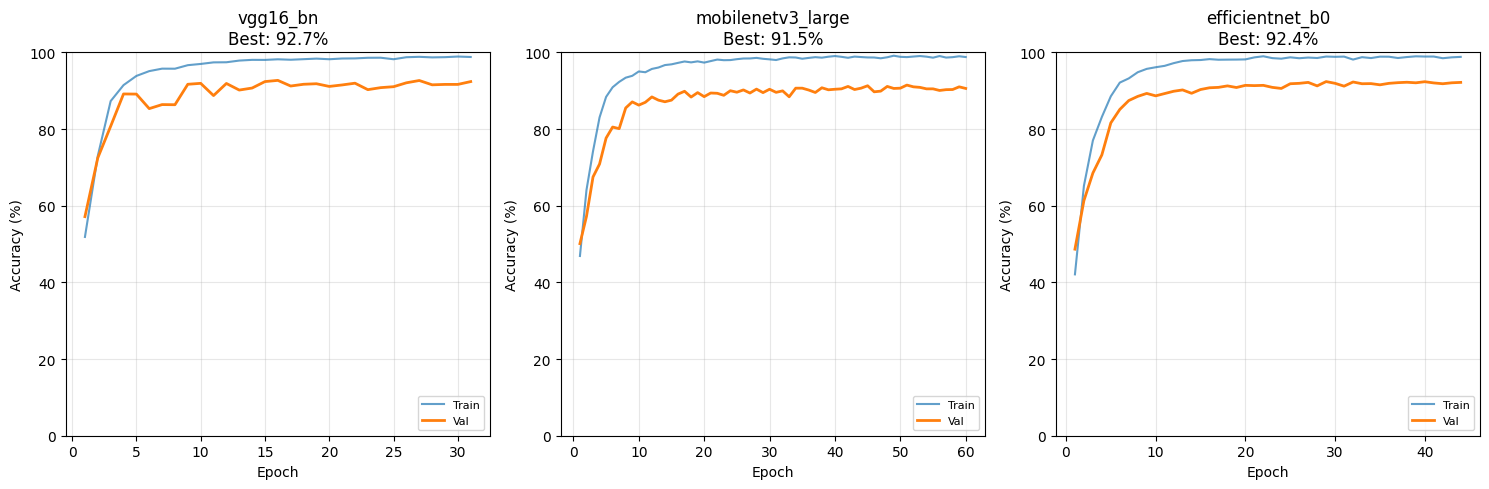

Training curves saved to part1_training_curves.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for idx, (model_name, results) in enumerate(all_results.items()):
    ax = axes[idx]
    history = results["history"]
    
    epochs_ran = len(history["val_acc"])
    ax.plot(range(1, epochs_ran + 1), history["train_acc"], label="Train", alpha=0.7)
    ax.plot(range(1, epochs_ran + 1), history["val_acc"], label="Val", linewidth=2)
    
    ax.set_title(f"{model_name}\nBest: {results['best_val_acc']:.1f}%")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim([0, 100])
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("part1_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Training curves saved to part1_training_curves.png")

## Noise Robustness Testing - Part 1

Evaluating Part 1 models across all SNR levels.
- **Training SNRs** (clean, +05dB, +15dB): evaluated on held-out 20% only (no data leakage)
- **Test SNRs** (+10dB, +20dB): evaluated on full data (never seen during training)
- **Validation SNR** (+00dB): evaluated on full data
- Metrics: Accuracy, F1 Score, FPR, FNR (macro-averaged across classes)

In [17]:
TASK_NUM_CLASSES = {"drone_type": config.num_drone_types, "flight_mode": config.num_flight_modes, "drone_count": config.num_drone_counts}


def compute_task_metrics(y_true, y_pred, num_classes):
    """Compute Accuracy, F1, macro-FPR, macro-FNR for a single task."""
    acc = accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    fpr_list, fnr_list = [], []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        fnr_list.append(fn / (fn + tp) if (fn + tp) > 0 else 0)
    return {"accuracy": acc, "f1": f1, "fpr": np.mean(fpr_list) * 100, "fnr": np.mean(fnr_list) * 100}


@torch.no_grad()
def evaluate_on_data(model, paths, dt, fm, dc, cfg):
    """Evaluate model on given data, return per-task metrics dict."""
    if len(paths) == 0:
        return None
    ds = RFSpectrogramDataset(paths, dt, fm, dc, transform=get_val_transforms(cfg))
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)
    all_preds = {t: [] for t in TASKS}
    all_labels = {t: [] for t in TASKS}
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        with autocast(dtype=torch.float16):
            logits = model(images)
        for t in TASKS:
            all_preds[t].extend(logits[t].argmax(1).cpu().tolist())
            all_labels[t].extend(labels[t].tolist())
    result = {}
    for t in TASKS:
        result[t] = compute_task_metrics(all_labels[t], all_preds[t], TASK_NUM_CLASSES[t])
    result["average"] = {
        "accuracy": np.mean([result[t]["accuracy"] for t in TASKS]),
        "f1": np.mean([result[t]["f1"] for t in TASKS]),
        "fpr": np.mean([result[t]["fpr"] for t in TASKS]),
        "fnr": np.mean([result[t]["fnr"] for t in TASKS]),
    }
    return result


def load_best_model(model_name: str, state_dict: dict) -> nn.Module:
    """Instantiates model and loads saved state dict."""
    model = MODEL_REGISTRY[model_name](pretrained=False)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model


def get_eval_data(snr_level, config, heldout_paths, heldout_dt, heldout_fm, heldout_dc, heldout_snr):
    """Get evaluation data for an SNR level: held-out 20% for training SNRs, full data for others."""
    if snr_level in config.train_snr_levels:
        mask = heldout_snr == snr_level
        paths = [p for p, m in zip(heldout_paths, mask) if m]
        dt, fm, dc = heldout_dt[mask], heldout_fm[mask], heldout_dc[mask]
        source = "held-out 20%"
    else:
        paths, dt, fm, dc, _ = load_partition(config.data_root, config.bands, (snr_level,))
        source = "full data"
    return paths, dt, fm, dc, source


print("Evaluation utilities defined (Accuracy, F1, FPR, FNR)")

Evaluation utilities defined (Accuracy, F1, FPR, FNR)


In [18]:
print("="*100)
print("DETAILED EVALUATION - PART 1")
print("="*100)

noise_results = {model_name: {} for model_name in all_results.keys()}
eval_levels = ["snr_clean", "snr_+20dB", "snr_+15dB", "snr_+10dB", "snr_+05dB", "snr_+00dB"]

for model_name, results in all_results.items():
    model = load_best_model(model_name, results["best_state"])
    
    # === Clean Data Evaluation (held-out 20%) ===
    print(f"\n{'='*100}")
    print(f"MODEL: {model_name.upper()}")
    print(f"{'='*100}")
    
    clean_paths, clean_dt, clean_fm, clean_dc, clean_src = get_eval_data(
        "snr_clean", config, heldout_paths, heldout_dt, heldout_fm, heldout_dc, heldout_snr
    )
    clean_result = evaluate_on_data(model, clean_paths, clean_dt, clean_fm, clean_dc, config)
    if clean_result:
        noise_results[model_name]["snr_clean"] = clean_result
        print(f"\n--- Clean Data ({clean_src}, n={len(clean_paths)}) ---")
        print(f"  {'Task':<15} {'Accuracy':>10} {'F1':>10} {'FPR':>10} {'FNR':>10}")
        print(f"  {'-'*55}")
        for t in TASKS:
            m = clean_result[t]
            print(f"  {t:<15} {m['accuracy']:>9.2f}% {m['f1']:>9.2f}% {m['fpr']:>9.2f}% {m['fnr']:>9.2f}%")
        avg = clean_result["average"]
        print(f"  {'AVERAGE':<15} {avg['accuracy']:>9.2f}% {avg['f1']:>9.2f}% {avg['fpr']:>9.2f}% {avg['fnr']:>9.2f}%")
    
    # === Per-SNR Evaluation ===
    for snr in eval_levels:
        if snr == "snr_clean":
            continue  # Already evaluated above
        paths, dt, fm, dc, src = get_eval_data(
            snr, config, heldout_paths, heldout_dt, heldout_fm, heldout_dc, heldout_snr
        )
        r = evaluate_on_data(model, paths, dt, fm, dc, config)
        if r:
            noise_results[model_name][snr] = r
            print(f"\n--- {snr} ({src}, n={len(paths)}) ---")
            print(f"  {'Task':<15} {'Accuracy':>10} {'F1':>10} {'FPR':>10} {'FNR':>10}")
            print(f"  {'-'*55}")
            for t in TASKS:
                m = r[t]
                print(f"  {t:<15} {m['accuracy']:>9.2f}% {m['f1']:>9.2f}% {m['fpr']:>9.2f}% {m['fnr']:>9.2f}%")
            avg = r["average"]
            print(f"  {'AVERAGE':<15} {avg['accuracy']:>9.2f}% {avg['f1']:>9.2f}% {avg['fpr']:>9.2f}% {avg['fnr']:>9.2f}%")
    
    del model
    torch.cuda.empty_cache()

print("\nDetailed evaluation complete")

DETAILED EVALUATION - PART 1

MODEL: VGG16_BN

--- Clean Data (held-out 20%, n=183) ---
  Task              Accuracy         F1        FPR        FNR
  -------------------------------------------------------
  drone_type          84.15%     84.78%      7.21%     13.63%
  flight_mode        100.00%    100.00%      0.00%      0.00%
  drone_count         89.07%     88.72%      8.05%     16.42%
  AVERAGE             91.07%     91.17%      5.09%     10.02%
  2.4GHz/snr_+20dB: 475 images
  5.8GHz/snr_+20dB: 475 images

--- snr_+20dB (full data, n=950) ---
  Task              Accuracy         F1        FPR        FNR
  -------------------------------------------------------
  drone_type          91.26%     91.42%      4.96%      9.06%
  flight_mode        100.00%    100.00%      0.00%      0.00%
  drone_count         93.05%     92.91%      5.31%     11.11%
  AVERAGE             94.77%     94.78%      3.42%      6.73%

--- snr_+15dB (held-out 20%, n=204) ---
  Task              Accuracy       


NOISE ROBUSTNESS SUMMARY - PART 1 (Drone Type Accuracy)

Model                        clean    +20dB    +15dB    +10dB    +05dB    +00dB
------------------------------------------------------------------------------------------
vgg16_bn                     84.2%    91.3%    96.6%    93.1%    96.7%    90.9%
mobilenetv3_large            82.5%    93.5%    94.6%    93.3%    94.5%    89.8%
efficientnet_b0              81.4%    92.8%    94.6%    94.0%    94.0%    91.2%

Source                         20%     100%      20%     100%      20%     100%


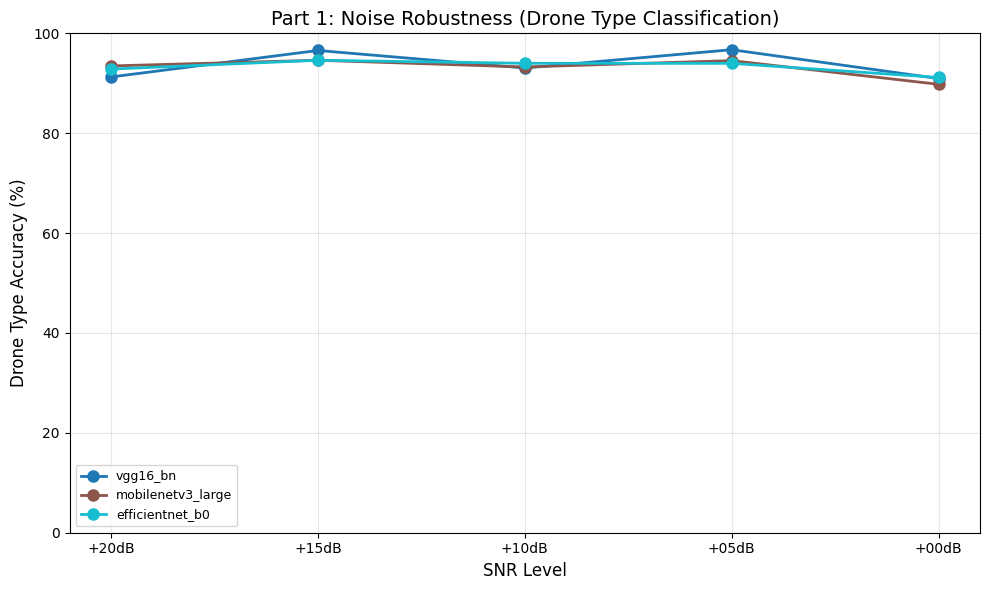

Noise robustness plot saved to part1_noise_robustness.png


In [19]:
print("\n" + "="*100)
print("NOISE ROBUSTNESS SUMMARY - PART 1 (Drone Type Accuracy)")
print("="*100)

snr_display = ["snr_clean", "snr_+20dB", "snr_+15dB", "snr_+10dB", "snr_+05dB", "snr_+00dB"]
snr_short = [s.replace("snr_", "") for s in snr_display]

# Accuracy table
print(f"\n{'Model':<25}" + "".join(f" {s:>8}" for s in snr_short))
print("-"*90)
for model_name in all_results.keys():
    row = f"{model_name:<25}"
    for snr in snr_display:
        if snr in noise_results[model_name]:
            acc = noise_results[model_name][snr]["drone_type"]["accuracy"]
            row += f" {acc:7.1f}%"
        else:
            row += "     N/A"
    print(row)

# Data source indicator
print(f"\n{'Source':<25}" + "".join(
    f" {'20%':>8}" if s in config.train_snr_levels else f" {'100%':>8}" for s in snr_display
))

fig, ax = plt.subplots(figsize=(10, 6))

snr_order = ["snr_+20dB", "snr_+15dB", "snr_+10dB", "snr_+05dB", "snr_+00dB"]
snr_labels_plot = ["+20dB", "+15dB", "+10dB", "+05dB", "+00dB"]
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for idx, (model_name, _) in enumerate(all_results.items()):
    accs = []
    for snr in snr_order:
        if snr in noise_results[model_name]:
            accs.append(noise_results[model_name][snr]["drone_type"]["accuracy"])
        else:
            accs.append(np.nan)
    ax.plot(range(len(snr_order)), accs, "o-", label=model_name, color=colors[idx], linewidth=2, markersize=8)

ax.set_xlabel("SNR Level", fontsize=12)
ax.set_ylabel("Drone Type Accuracy (%)", fontsize=12)
ax.set_title("Part 1: Noise Robustness (Drone Type Classification)", fontsize=14)
ax.set_xticks(range(len(snr_order)))
ax.set_xticklabels(snr_labels_plot)
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig("part1_noise_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

print("Noise robustness plot saved to part1_noise_robustness.png")

## Save All Artifacts and Create ZIP - Part 1

Saves model weights, training histories, noise robustness results, and creates downloadable zip file.

In [20]:
OUTPUT_DIR = "part1_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Saving best model weights for Part 1 architectures...")
for model_name, results in all_results.items():
    torch.save(results["best_state"], f"{OUTPUT_DIR}/best_{model_name}.pth")
    print(f"  {model_name}: Acc={results['best_val_acc']:.2f}%")

results_summary = {
    "part": 1,
    "timestamp": datetime.now().isoformat(),
    "training_strategy": "noise_robust",
    "train_snr": list(config.train_snr_levels),
    "val_snr": list(config.val_snr_levels),
    "test_snr": list(config.test_snr_levels),
    "config": {
        "batch_size": config.batch_size,
        "learning_rate": config.learning_rate,
        "epochs": config.epochs,
        "patience": config.patience,
    },
    "models": {
        name: {
            "best_val_acc": r["best_val_acc"],
            "per_task": {
                task: {
                    "accuracy": r["best_metrics"][task]["accuracy"],
                    "f1_score": r["best_metrics"][task]["f1_score"]
                } for task in TASKS
            }
        } for name, r in all_results.items()
    },
    "noise_robustness": {
        model_name: {
            snr: {
                t: {k: round(v, 2) for k, v in data[t].items()} if isinstance(data[t], dict) else round(data[t], 2)
                for t in list(TASKS) + ["average"]
            }
            for snr, data in snr_data.items()
        } for model_name, snr_data in noise_results.items()
    }
}

with open(f"{OUTPUT_DIR}/part1_results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)
print("Saved part1_results_summary.json")

with open(f"{OUTPUT_DIR}/part1_histories.pkl", "wb") as f:
    pickle.dump({name: r["history"] for name, r in all_results.items()}, f)
print("Saved part1_histories.pkl")

with open(f"{OUTPUT_DIR}/part1_noise_results.pkl", "wb") as f:
    pickle.dump(noise_results, f)
print("Saved part1_noise_results.pkl")

if os.path.exists("part1_training_curves.png"):
    shutil.copy("part1_training_curves.png", f"{OUTPUT_DIR}/part1_training_curves.png")
    print("Saved part1_training_curves.png")

if os.path.exists("part1_noise_robustness.png"):
    shutil.copy("part1_noise_robustness.png", f"{OUTPUT_DIR}/part1_noise_robustness.png")
    print("Saved part1_noise_robustness.png")

zip_name = f"cnn_transformer_part1_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
shutil.make_archive(zip_name, "zip", OUTPUT_DIR)
print(f"\n{'='*70}")
print(f"FINAL ZIP CREATED: {zip_name}.zip")
print(f"{'='*70}")
print(f"\nContents: {os.listdir(OUTPUT_DIR)}")

try:
    from IPython.display import FileLink, display
    display(FileLink(f"{zip_name}.zip"))
except ImportError:
    print(f"Download: {os.path.abspath(zip_name)}.zip")

Saving best model weights for Part 1 architectures...
  vgg16_bn: Acc=92.70%
  mobilenetv3_large: Acc=91.47%
  efficientnet_b0: Acc=92.39%
Saved part1_results_summary.json
Saved part1_histories.pkl
Saved part1_noise_results.pkl
Saved part1_training_curves.png
Saved part1_noise_robustness.png

FINAL ZIP CREATED: cnn_transformer_part1_20260212_032326.zip

Contents: ['best_vgg16_bn.pth', 'part1_noise_robustness.png', 'best_efficientnet_b0.pth', 'best_mobilenetv3_large.pth', 'part1_histories.pkl', 'part1_results_summary.json', 'part1_training_curves.png', 'part1_noise_results.pkl']


/kaggle/working/cnn_transformer_part1_20260212_032326.zip